# Notebook 2 - Inverse dynamica, onbalans en actuatoranalyse

**Vak:** Beweging en Trillingen

## Probleemstelling

Inverse dynamica van het paraplu-stangenmechanisme: kinematica (uit `notebook1_kinematica_results.npz`) is gekend, de krachten worden berekend. Per bewegende link (2-8) + puntmassa $K$ worden de Newton-Euler-vergelijkingen opgesteld:

$$\sum F_x = m a_x,\qquad \sum F_y = m a_y,\qquad \sum M_{cg} = J_{cg}\alpha,$$

samengebracht in één stelsel $A\mathbf w=\mathbf b$ per tijdstap (21 onbekenden $\mathbf w$: aandrijfkracht, frame-reacties, interne gewrichtskrachten).

> **Inertie-only**: zwaartekracht, wind, wrijving en elastische voorspanning zijn niet opgenomen → houdkracht in stilstand is hier 0. Volledige belastingsanalyse: **Notebook 3**. Definitieve aandrijving (motor + as + riem/kabel + rem): **Notebook 4**.

## Sleutelwaarden

| Grootheid | Symbool | Waarde |
|-----------|---------|--------|
| Totale bewegende modelmassa (incl. K) | $m_{tot}$ | **7,4998 kg** ($m_K$=3,00 kg, schuiver=1,50 kg, links 2-8 samen 4,00 kg) |
| Lijnmassa stangen | $\rho_L$ | 0,5500 kg/m (Al-buis Ø30×2mm, $\rho$=2700 kg/m³, + 0,075 kg/m beslag) |
| Globale dyn. controle (kracht-/momentbalans) | residual | **5,5×10⁻¹⁶** → machineprecisie ✓ |
| cond(A) bereik (21×21 stelsel) | cond(A) | **18,77 – 216,68** |
| Aandrijfkracht (bereik) | $F_{drive,s}$ | **-2,994 N ↔ +0,364 N** |
| Piek / RMS dynamische schuifkracht | $F_{peak}/F_{rms}$ | **2,994 N / 1,108 N** |
| Inertiële kracht in hold-fase | $F_{hold}$ | **0,0 N** (model zonder zwaartekracht/wrijving) |
| Max. onbalanskracht | $\Vert\vec F_{shak}\Vert_{max}$ | **0,4996 N** |
| Onbalansmoment rond C (bereik) | $M_{shak,C}$ | **-0,809 ↔ +0,516 Nm** |
| Actuatorvermogen (bereik) | $P_{act}$ | **-0,060 ↔ +0,101 W** |
| Piek aandrijf- / regen.vermogen | $P_{+}/P_{regen}$ | **0,195 W / 0,070 W** |
| Equivalent motorkoppel (piek / RMS) | $T_{motor}$ | **0,1440 / 0,0533 Nm** |
| Piek motortoerental | $n_{motor,max}$ | **75,1 rpm** |
| Arbeids-surplus (energiebuffer) | $A_{max}$ | **0,2541 J** |
| Max. energiebalansfout | $\varepsilon_{E,max}$ | **1,1×10⁻⁴ J** $\ll E_{kin,max}$=0,254 J ✓ |

### Vergelijking aandrijfprincipes (inertie-only equivalent)

| Aandrijfprincipe | Krachtformule | Geschikt voor brede overdekking (NB4)? | Opmerking |
|---|---|---|---|
| Schroefspindel | $F=2\pi\eta T/\text{spoed}$ | Nee | enkel behouden als `screw_lead`-compatibiliteitsalias |
| **Poelie/riem + roterende motor** ✓ | $T_{motor}=\dfrac{F_s\,d_{travel}}{2\pi\eta}$, $d_{travel}=2\pi r_{poelie}$=0,1571 m/omw | **Ja** | **Gekozen**: één centrale motor + as kan via riemen/kabels meerdere ribben aandrijven |

### Kernvergelijkingen

$$\sum F_x=ma_x,\quad \sum F_y=ma_y,\quad \sum M_{cg}=J_{cg}\alpha \quad\Rightarrow\quad A\mathbf w=\mathbf b \ \ \text{(21 onbekenden)}$$

$$F_{drive,s}=-F_{actuator,y},\qquad \mathbf F_{shak}=-(\mathbf F_A+\mathbf F_C),\qquad M_{shak,C}=-(M_A+\mathbf r_{CA}\times\mathbf F_A)$$

$$P_{act}=F_s\dot s,\qquad T_{motor}=\frac{F_s\,d_{travel}}{2\pi\eta},\qquad A_{max}=\max_t\!\int_0^t(P-\bar P)dt-\min_t\!\int_0^t(P-\bar P)dt$$

## Setup en data uit Notebook 1

Laadt alle kinematische resultaten (tijd, $s$, hoeken, snelheden, versnellingen, $K$, geometrie) uit `notebook1_kinematica_results.npz`. Bij parameterwijziging: Notebook 1 eerst volledig herrunnen.

In [11]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

kinematics_path = Path("notebook1_kinematica_results.npz")
if not kinematics_path.exists():
    raise FileNotFoundError("Run eerst 'Notebook 1.ipynb' zodat notebook1_kinematica_results.npz bestaat.")

required_keys = [
    "t", "Ts", "s", "ds", "dds",
    "theta3", "theta4", "theta5", "theta6", "theta7", "theta8",
    "dtheta3", "dtheta4", "dtheta5", "dtheta6", "dtheta7", "dtheta8",
    "ddtheta3", "ddtheta4", "ddtheta5", "ddtheta6", "ddtheta7", "ddtheta8",
    "Kx", "Ky", "Kdot_x", "Kdot_y", "Kdot_norm", "Kddot_x", "Kddot_y", "Kddot_norm",
    "cond", "residual_pos",
    "L1", "r3a", "r3b", "r4a", "r4b", "r5a", "r5b", "r6", "r7a", "r7b", "r8a", "r8b",
]
data = np.load(kinematics_path)
missing = [key for key in required_keys if key not in data.files]
if missing:
    raise KeyError(f"Ontbrekende keys in {kinematics_path}: {missing}")

t = data["t"]; Ts = float(data["Ts"]); s = data["s"]; ds = data["ds"]; dds = data["dds"]
theta3 = data["theta3"]; theta4 = data["theta4"]; theta5 = data["theta5"]
theta6 = data["theta6"]; theta7 = data["theta7"]; theta8 = data["theta8"]
dtheta3 = data["dtheta3"]; dtheta4 = data["dtheta4"]; dtheta5 = data["dtheta5"]
dtheta6 = data["dtheta6"]; dtheta7 = data["dtheta7"]; dtheta8 = data["dtheta8"]
ddtheta3 = data["ddtheta3"]; ddtheta4 = data["ddtheta4"]; ddtheta5 = data["ddtheta5"]
ddtheta6 = data["ddtheta6"]; ddtheta7 = data["ddtheta7"]; ddtheta8 = data["ddtheta8"]
Kx = data["Kx"]; Ky = data["Ky"]; Kdot_x = data["Kdot_x"]; Kdot_y = data["Kdot_y"]
Kdot_norm = data["Kdot_norm"]; Kddot_x = data["Kddot_x"]; Kddot_y = data["Kddot_y"]; Kddot_norm = data["Kddot_norm"]
cond = data["cond"]; residual_pos = data["residual_pos"]
L1 = float(data["L1"]); r3a = float(data["r3a"]); r3b = float(data["r3b"])
r4a = float(data["r4a"]); r4b = float(data["r4b"]); r5a = float(data["r5a"]); r5b = float(data["r5b"])
r6 = float(data["r6"]); r7a = float(data["r7a"]); r7b = float(data["r7b"]); r8a = float(data["r8a"]); r8b = float(data["r8b"])

n_steps = len(t)
T_cycle = float(t[-1] - t[0])
if T_cycle <= 0:
    raise ValueError("De tijdvector uit Notebook 1 heeft geen positieve cyclusduur.")

print("Kinematische data ingeladen uit:")
print(kinematics_path.resolve())
print(f"Aantal tijdstappen: {n_steps}")
print(f"Cyclusduur: {T_cycle:.4f} s")
print(f"Maximale sluitingsfout uit Notebook 1: {np.max(residual_pos):.3e}")

Kinematische data ingeladen uit:
C:\Users\WELL_ASUS_BUP\OneDrive\Alexandre\KUL\Semester 6\Beweging\Bewegingen-trillingen-project\project\notebooks\Stangen\notebook1_kinematica_results.npz
Aantal tijdstappen: 481
Cyclusduur: 24.0000 s
Maximale sluitingsfout uit Notebook 1: 4.718e-13


## Dynamische parameters

- **Stangmassa**: lijnmassa $\rho_L$ = aluminium buis (Ø30×2mm, $\rho$=2700 kg/m³) + beslagtoeslag → $m_i=\rho_L L_i$, $J_i=m_iL_i^2/12$ (zie Sleutelwaarden).
- **Puntmassa K**: doek/rand/rib-massa, opgenomen in de Newton-Euler-vergelijkingen van link 8 (zodat het moment door $\ddot{\vec K}$ meetelt) — niet bij $m_8$ opgeteld.
- **Aandrijving**: gecontroleerde schuiverkracht + poelie/riem-equivalent voor een roterende motor (zie Vergelijking aandrijfprincipes hierboven). Statische lasten (zwaartekracht, wind, wrijving, voorspanning) ontbreken nog.

In [12]:
L2 = 0.0
L3 = r3a + r3b
L4 = r4a + r4b
L5 = r5a + r5b
L6 = r6
L7 = r7a + r7b
L8 = r8a + r8b

# Eerste realistische massa-inschatting voor een grote terras-/cafeparaplu.
# De stangmassa wordt fysisch opgebouwd uit een aluminium buisprofiel plus beslagtoeslag.
slider_mass = 1.50          # [kg] schuiver/collar rond de mast
rod_outer_diameter = 0.030  # [m] ronde aluminium stang/buis, buitendiameter 30 mm
rod_wall_thickness = 0.002  # [m] wanddikte 2 mm
rod_material_density = 2700.0  # [kg/m^3] aluminium
rod_fittings_line_mass_allowance = 0.075  # [kg/m] scharnieren, bouten, eindstukken, lokale verstevigingen
rod_inner_diameter = rod_outer_diameter - 2.0 * rod_wall_thickness
if rod_inner_diameter <= 0:
    raise ValueError("rod_wall_thickness is te groot voor rod_outer_diameter.")
rod_tube_area = np.pi / 4.0 * (rod_outer_diameter**2 - rod_inner_diameter**2)
rod_tube_mass_per_m = rod_tube_area * rod_material_density
line_mass_density = rod_tube_mass_per_m + rod_fittings_line_mass_allowance
payload_mass_K = 3.00       # [kg] equivalente doek/rand/rib-massa geconcentreerd in K
mass_scale = 1.0
inertia_scale = 1.0         # enkel rotatie-inertie schalen; meestal 1.0 laten

masses = {
    2: slider_mass * mass_scale,
    3: line_mass_density * L3 * mass_scale,
    4: line_mass_density * L4 * mass_scale,
    5: line_mass_density * L5 * mass_scale,
    6: line_mass_density * L6 * mass_scale,
    7: line_mass_density * L7 * mass_scale,
    8: line_mass_density * L8 * mass_scale,
}
inertias = {
    2: 0.0,
    3: masses[3] * L3**2 / 12 * inertia_scale,
    4: masses[4] * L4**2 / 12 * inertia_scale,
    5: masses[5] * L5**2 / 12 * inertia_scale,
    6: masses[6] * L6**2 / 12 * inertia_scale,
    7: masses[7] * L7**2 / 12 * inertia_scale,
    8: masses[8] * L8**2 / 12 * inertia_scale,
}

# Lineaire schuiverkracht en poelie/riem-equivalent voor een roterende motor.
# Notebook 4 doet de definitieve motor-, rem- en poeliekeuze.
actuator_efficiency = 0.78
actuator_safety_factor = 1.50
drive_pulley_radius_nb2 = 0.025    # [m] referentiepoelie voor inertie-only quick check
drive_travel_per_rev_nb2 = 2 * np.pi * drive_pulley_radius_nb2  # [m/omw] riemverplaatsing per poelie-omwenteling
screw_lead = drive_travel_per_rev_nb2  # compatibility alias; geen schroefspindel in dit ontwerp

moving_link_mass = sum(masses.values())
total_model_mass = moving_link_mass + payload_mass_K

print("Dynamische parameters:")
for link_id in range(2, 9):
    print(f"link {link_id}: m = {masses[link_id]:.4f} kg, J = {inertias[link_id]:.5f} kg m^2")
print(f"puntmassa K: m = {payload_mass_K:.4f} kg")
print(f"totale bewegende modelmassa incl. K = {total_model_mass:.4f} kg")
print()
print(f"stangprofiel: aluminium buis {1000*rod_outer_diameter:.0f}x{1000*rod_wall_thickness:.1f} mm "
      f"+ beslagtoeslag {rod_fittings_line_mass_allowance:.3f} kg/m")
print(f"lijnmassa stangen = {line_mass_density:.4f} kg/m")
print()
print("Actuatorparameters:")
print(f"drive_pulley_radius_nb2 = {drive_pulley_radius_nb2*1000:.1f} mm")
print(f"drive_travel_per_rev_nb2 = {drive_travel_per_rev_nb2:.4f} m/omw")
print(f"actuator_efficiency = {actuator_efficiency:.2f}")


Dynamische parameters:
link 2: m = 1.5000 kg, J = 0.00000 kg m^2
link 3: m = 0.5148 kg, J = 0.03757 kg m^2
link 4: m = 0.8784 kg, J = 0.18669 kg m^2
link 5: m = 0.3608 kg, J = 0.01294 kg m^2
link 6: m = 0.3742 kg, J = 0.01444 kg m^2
link 7: m = 0.3742 kg, J = 0.01444 kg m^2
link 8: m = 0.4974 kg, J = 0.03390 kg m^2
puntmassa K: m = 3.0000 kg
totale bewegende modelmassa incl. K = 7.4998 kg

stangprofiel: aluminium buis 30x2.0 mm + beslagtoeslag 0.075 kg/m
lijnmassa stangen = 0.5500 kg/m

Actuatorparameters:
drive_pulley_radius_nb2 = 25.0 mm
drive_travel_per_rev_nb2 = 0.1571 m/omw
actuator_efficiency = 0.78


## Rigid-body kinematica

Posities/snelheden/versnellingen van de zwaartepunten via algemene rigid-body formules:

$$\mathbf v_P=\mathbf v_O+\omega\times\mathbf r_{OP},\qquad \mathbf a_P=\mathbf a_O+\alpha\times\mathbf r_{OP}-\omega^2\mathbf r_{OP}.$$

In [13]:
def perp(v):
    v = np.asarray(v)
    return np.column_stack((-v[:, 1], v[:, 0])) if v.ndim == 2 else np.array([-v[1], v[0]])

def rigid_point(ref_pos, ref_vel, ref_acc, theta, omega, alpha, local_vector):
    local_vector = np.asarray(local_vector, dtype=float)
    r_global = np.column_stack((
        local_vector[0] * np.cos(theta) - local_vector[1] * np.sin(theta),
        local_vector[0] * np.sin(theta) + local_vector[1] * np.cos(theta),
    ))
    pos = ref_pos + r_global
    vel = ref_vel + omega[:, None] * perp(r_global)
    acc = ref_acc + alpha[:, None] * perp(r_global) - (omega[:, None] ** 2) * r_global
    return pos, vel, acc

zero = np.zeros(n_steps)
zeros2 = np.zeros((n_steps, 2))

C_pos = zeros2.copy(); C_vel = zeros2.copy(); C_acc = zeros2.copy()
B_pos = np.column_stack((zero, -s))
B_vel = np.column_stack((zero, -ds))
B_acc = np.column_stack((zero, -dds))

D_pos, D_vel, D_acc = rigid_point(B_pos, B_vel, B_acc, theta3, dtheta3, ddtheta3, [r3a, 0.0])
E3_pos, _, _ = rigid_point(B_pos, B_vel, B_acc, theta3, dtheta3, ddtheta3, [r3a + r3b, 0.0])
E4_pos, _, _ = rigid_point(C_pos, C_vel, C_acc, theta4, dtheta4, ddtheta4, [r4a, 0.0])
E_pos = 0.5 * (E3_pos + E4_pos)
H_pos, H_vel, H_acc = rigid_point(C_pos, C_vel, C_acc, theta4, dtheta4, ddtheta4, [r4a + r4b, 0.0])
F_pos, F_vel, F_acc = rigid_point(D_pos, D_vel, D_acc, theta5, dtheta5, ddtheta5, [r5a, 0.0])
G5_pos, _, _ = rigid_point(D_pos, D_vel, D_acc, theta5, dtheta5, ddtheta5, [r5a + r5b, 0.0])
G7_pos, _, _ = rigid_point(H_pos, H_vel, H_acc, theta7, dtheta7, ddtheta7, [-r7a, 0.0])
G_pos = 0.5 * (G5_pos + G7_pos)
I_pos, I_vel, I_acc = rigid_point(F_pos, F_vel, F_acc, theta6, dtheta6, ddtheta6, [r6, 0.0])
J7_pos, _, _ = rigid_point(H_pos, H_vel, H_acc, theta7, dtheta7, ddtheta7, [r7b, 0.0])
J8_pos, _, _ = rigid_point(I_pos, I_vel, I_acc, theta8, dtheta8, ddtheta8, [r8a, 0.0])
J_pos = 0.5 * (J7_pos + J8_pos)
K_pos, K_vel, K_acc = rigid_point(I_pos, I_vel, I_acc, theta8, dtheta8, ddtheta8, [r8a + r8b, 0.0])

cg_pos, cg_vel, cg_acc, alpha = {}, {}, {}, {}
cg_pos[2] = B_pos.copy(); cg_vel[2] = B_vel.copy(); cg_acc[2] = B_acc.copy(); alpha[2] = zero.copy()
cg_pos[3], cg_vel[3], cg_acc[3] = rigid_point(B_pos, B_vel, B_acc, theta3, dtheta3, ddtheta3, [L3 / 2, 0.0]); alpha[3] = ddtheta3
cg_pos[4], cg_vel[4], cg_acc[4] = rigid_point(C_pos, C_vel, C_acc, theta4, dtheta4, ddtheta4, [L4 / 2, 0.0]); alpha[4] = ddtheta4
cg_pos[5], cg_vel[5], cg_acc[5] = rigid_point(D_pos, D_vel, D_acc, theta5, dtheta5, ddtheta5, [L5 / 2, 0.0]); alpha[5] = ddtheta5
cg_pos[6], cg_vel[6], cg_acc[6] = rigid_point(F_pos, F_vel, F_acc, theta6, dtheta6, ddtheta6, [L6 / 2, 0.0]); alpha[6] = ddtheta6
cg_pos[7], cg_vel[7], cg_acc[7] = rigid_point(H_pos, H_vel, H_acc, theta7, dtheta7, ddtheta7, [(r7b - r7a) / 2, 0.0]); alpha[7] = ddtheta7
cg_pos[8], cg_vel[8], cg_acc[8] = rigid_point(I_pos, I_vel, I_acc, theta8, dtheta8, ddtheta8, [L8 / 2, 0.0]); alpha[8] = ddtheta8

K_loaded = np.column_stack((Kx, Ky))
print("Rigid-body kinematica opgebouwd.")
print(f"max |K_reconstructie - K_Notebook1| = {np.max(np.linalg.norm(K_pos - K_loaded, axis=1)):.3e} m")
print(f"max sluitverschil E/G/J = {np.max(np.linalg.norm(E3_pos - E4_pos, axis=1)):.3e} / {np.max(np.linalg.norm(G5_pos - G7_pos, axis=1)):.3e} / {np.max(np.linalg.norm(J7_pos - J8_pos, axis=1)):.3e} m")

Rigid-body kinematica opgebouwd.
max |K_reconstructie - K_Notebook1| = 4.965e-16 m
max sluitverschil E/G/J = 4.718e-13 / 4.721e-13 / 4.721e-13 m


## Inverse dynamica

21 onbekenden: $R_{Ax}$, $F_{act,y}$, $M_A$ (schuiver A) + reactiekrachten in B...J. Tekenconventie: een onbekende kracht is positief op één link en komt met tegengesteld teken terug op de verbonden link.

In [14]:
unknown_labels = [
    "R_Ax", "F_act_y", "M_A", "C_x", "C_y", "B_x", "B_y", "D_x", "D_y", "E_x", "E_y",
    "F_x", "F_y", "G_x", "G_y", "H_x", "H_y", "I_x", "I_y", "J_x", "J_y",
]
unknown_index = {name: i for i, name in enumerate(unknown_labels)}
n_unknowns = len(unknown_labels)

def moment_2d(r, F):
    return r[0] * F[1] - r[1] * F[0]

def add_link_equations(A, b, row, m, J, a_cg, alpha_cg, cg, forces, moments=None, point_masses=None):
    moments = moments or []
    point_masses = point_masses or []
    row_fx, row_fy, row_m = row, row + 1, row + 2
    for fx_name, fy_name, sign, point in forces:
        r = point - cg
        if fx_name is not None:
            j = unknown_index[fx_name]
            A[row_fx, j] += sign
            A[row_m, j] += -sign * r[1]
        if fy_name is not None:
            j = unknown_index[fy_name]
            A[row_fy, j] += sign
            A[row_m, j] += sign * r[0]
    for moment_name, sign in moments:
        A[row_m, unknown_index[moment_name]] += sign

    F_inertia = m * a_cg
    M_inertia = J * alpha_cg
    for point_mass, point_acc, point_pos in point_masses:
        F_point = point_mass * point_acc
        F_inertia = F_inertia + F_point
        M_inertia = M_inertia + moment_2d(point_pos - cg, F_point)

    b[row_fx] = F_inertia[0]
    b[row_fy] = F_inertia[1]
    b[row_m] = M_inertia
    return row + 3

def build_inverse_dynamics_system(k, masses_local=None, inertias_local=None):
    masses_local = masses if masses_local is None else masses_local
    inertias_local = inertias if inertias_local is None else inertias_local
    A = np.zeros((n_unknowns, n_unknowns))
    b = np.zeros(n_unknowns)
    row = 0
    row = add_link_equations(A, b, row, masses_local[2], inertias_local[2], cg_acc[2][k], alpha[2][k], cg_pos[2][k],
                             [("R_Ax", None, 1.0, B_pos[k]), (None, "F_act_y", 1.0, B_pos[k]), ("B_x", "B_y", 1.0, B_pos[k])],
                             [("M_A", 1.0)])
    row = add_link_equations(A, b, row, masses_local[3], inertias_local[3], cg_acc[3][k], alpha[3][k], cg_pos[3][k],
                             [("B_x", "B_y", -1.0, B_pos[k]), ("D_x", "D_y", 1.0, D_pos[k]), ("E_x", "E_y", 1.0, E_pos[k])])
    row = add_link_equations(A, b, row, masses_local[4], inertias_local[4], cg_acc[4][k], alpha[4][k], cg_pos[4][k],
                             [("C_x", "C_y", 1.0, C_pos[k]), ("E_x", "E_y", -1.0, E_pos[k]), ("H_x", "H_y", 1.0, H_pos[k])])
    row = add_link_equations(A, b, row, masses_local[5], inertias_local[5], cg_acc[5][k], alpha[5][k], cg_pos[5][k],
                             [("D_x", "D_y", -1.0, D_pos[k]), ("F_x", "F_y", 1.0, F_pos[k]), ("G_x", "G_y", 1.0, G_pos[k])])
    row = add_link_equations(A, b, row, masses_local[6], inertias_local[6], cg_acc[6][k], alpha[6][k], cg_pos[6][k],
                             [("F_x", "F_y", -1.0, F_pos[k]), ("I_x", "I_y", 1.0, I_pos[k])])
    row = add_link_equations(A, b, row, masses_local[7], inertias_local[7], cg_acc[7][k], alpha[7][k], cg_pos[7][k],
                             [("G_x", "G_y", -1.0, G_pos[k]), ("H_x", "H_y", -1.0, H_pos[k]), ("J_x", "J_y", 1.0, J_pos[k])])
    row = add_link_equations(A, b, row, masses_local[8], inertias_local[8], cg_acc[8][k], alpha[8][k], cg_pos[8][k],
                             [("I_x", "I_y", -1.0, I_pos[k]), ("J_x", "J_y", -1.0, J_pos[k])],
                             point_masses=[(payload_mass_K, K_acc[k], K_pos[k])])
    if row != n_unknowns:
        raise RuntimeError(f"Verkeerd aantal vergelijkingen: {row} i.p.v. {n_unknowns}")
    return A, b

A_all = np.zeros((n_steps, n_unknowns, n_unknowns))
b_all = np.zeros((n_steps, n_unknowns))
w_all = np.zeros((n_steps, n_unknowns))
dyn_residual = np.zeros(n_steps)
dyn_cond = np.zeros(n_steps)
for k in range(n_steps):
    A_k, b_k = build_inverse_dynamics_system(k)
    A_all[k] = A_k; b_all[k] = b_k
    dyn_cond[k] = np.linalg.cond(A_k)
    w_all[k] = np.linalg.solve(A_k, b_k)
    dyn_residual[k] = np.linalg.norm(A_k @ w_all[k] - b_k)

for name, idx in unknown_index.items():
    globals()[name] = w_all[:, idx]
F_actuator_y = F_act_y
F_drive_s = -F_actuator_y
M_guide_A = M_A

print("Inverse dynamica opgelost over het volledige bewegingsbereik.")
print(f"Maximum residu ||A w - b|| = {np.max(dyn_residual):.3e}")
print(f"Gemiddeld residu           = {np.mean(dyn_residual):.3e}")
print(f"cond(A_dyn) min/gem/max    = {np.min(dyn_cond):.3e} / {np.mean(dyn_cond):.3e} / {np.max(dyn_cond):.3e}")
print(f"max |F_drive_s|            = {np.max(np.abs(F_drive_s)):.3f} N")

Inverse dynamica opgelost over het volledige bewegingsbereik.
Maximum residu ||A w - b|| = 5.468e-16
Gemiddeld residu           = 9.988e-17
cond(A_dyn) min/gem/max    = 1.877e+01 / 7.257e+01 / 2.167e+02
max |F_drive_s|            = 2.994 N


## Controle van de dynamische oplossing

Globale check: som van externe frame-/actuatorkrachten = totale inertiële resultante van alle bewegende links + K; idem voor het moment rond $C$. Resultaat: zie Sleutelwaarden (machineprecisie).

In [15]:
F_A_on_mechanism = np.column_stack((R_Ax, F_actuator_y))
F_C_on_mechanism = np.column_stack((C_x, C_y))
F_external_total = F_A_on_mechanism + F_C_on_mechanism
F_inertia_total = np.zeros((n_steps, 2))
M_inertia_about_C = np.zeros(n_steps)
M_external_about_C = np.zeros(n_steps)
for k in range(n_steps):
    for link_id in range(2, 9):
        F_i = masses[link_id] * cg_acc[link_id][k]
        F_inertia_total[k] += F_i
        M_inertia_about_C[k] += moment_2d(cg_pos[link_id][k] - C_pos[k], F_i) + inertias[link_id] * alpha[link_id][k]
    F_K = payload_mass_K * K_acc[k]
    F_inertia_total[k] += F_K
    M_inertia_about_C[k] += moment_2d(K_pos[k] - C_pos[k], F_K)
    M_external_about_C[k] = M_guide_A[k] + moment_2d(B_pos[k] - C_pos[k], F_A_on_mechanism[k])

force_balance_error = np.linalg.norm(F_external_total - F_inertia_total, axis=1)
moment_balance_error = np.abs(M_external_about_C - M_inertia_about_C)
print("Globale dynamische controle:")
print(f"max ||F_ext - som m a_cg||       = {np.max(force_balance_error):.3e} N")
print(f"max |M_ext,C - M_inertie,C|   = {np.max(moment_balance_error):.3e} Nm")
print(f"max |M_A|                     = {np.max(np.abs(M_guide_A)):.3e} Nm")

Globale dynamische controle:
max ||F_ext - som m a_cg||       = 6.961e-16 N
max |M_ext,C - M_inertie,C|   = 4.441e-16 Nm
max |M_A|                     = 0.000e+00 Nm


## Energiebalans-validatie

Vermogensstelling voor inertie-only systeem:

$$P_\text{actuator}(t)=\frac{d}{dt}\sum_i\left(\tfrac12 m_iv_{cg,i}^2+\tfrac12 J_i\omega_i^2\right)$$

Restfout (numeriek, centrale differentie van $E_{kin}$): zie Sleutelwaarden — globale controle van het volledige $A\mathbf w=\mathbf b$ stelsel.

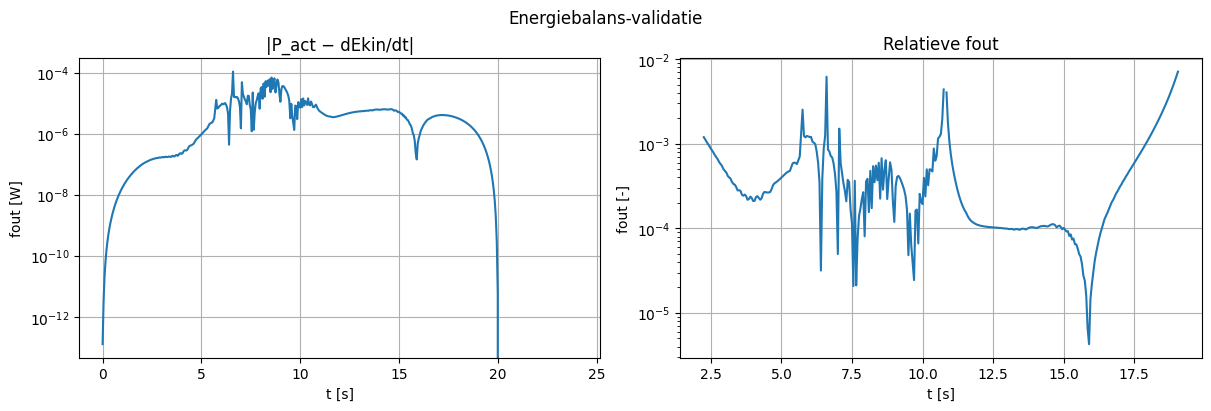

Energiebalans max abs. fout : 1.069e-04 W
Energiebalans max rel. fout : 7.134e-03


In [16]:
# Energiebalans-validatie: P_act = dEkin/dt (inertie-only)

# Kinetische energie van alle links + puntmassa K
Ekin_nb2 = np.zeros(n_steps)

# Link 2: schuiver (puur translatie, geen rotatie)
Ekin_nb2 += 0.5 * masses[2] * np.sum(cg_vel[2]**2, axis=1)

# Links 3-8: translatie + rotatie
omega_nb2 = {3: dtheta3, 4: dtheta4, 5: dtheta5, 6: dtheta6, 7: dtheta7, 8: dtheta8}
for link_id in range(3, 9):
    Ekin_nb2 += (0.5 * masses[link_id] * np.sum(cg_vel[link_id]**2, axis=1)
                 + 0.5 * inertias[link_id] * omega_nb2[link_id]**2)

# Puntmassa K
Ekin_nb2 += 0.5 * payload_mass_K * np.sum(K_vel**2, axis=1)

# Numerieke afgeleide via centrale differenties
dEkin_dt_nb2 = np.gradient(Ekin_nb2, t)

# Energiebalans: P_act - dEkin/dt (moet ≈ 0)
energy_balance_error_nb2 = F_drive_s * ds - dEkin_dt_nb2

denom_nb2 = np.where(np.abs(F_drive_s * ds) > 1e-4, F_drive_s * ds, np.nan)
energy_balance_rel_nb2 = np.abs(energy_balance_error_nb2 / denom_nb2)

fig_eb2, ax_eb2 = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig_eb2.suptitle("Energiebalans-validatie")

ax_eb2[0].plot(t, np.abs(energy_balance_error_nb2))
ax_eb2[0].set_title("|P_act − dEkin/dt|")
ax_eb2[0].set_yscale("log")
ax_eb2[0].set_xlabel("t [s]")
ax_eb2[0].set_ylabel("fout [W]")
ax_eb2[0].grid(True)

ax_eb2[1].plot(t, energy_balance_rel_nb2)
ax_eb2[1].set_title("Relatieve fout")
ax_eb2[1].set_yscale("log")
ax_eb2[1].set_xlabel("t [s]")
ax_eb2[1].set_ylabel("fout [-]")
ax_eb2[1].grid(True)

plt.show()
print(f"Energiebalans max abs. fout : {np.nanmax(np.abs(energy_balance_error_nb2)):.3e} W")
print(f"Energiebalans max rel. fout : {np.nanmax(energy_balance_rel_nb2):.3e}")

## Krachten en onbalans

$$F_{drive,s}=-F_{actuator,y}\quad(s\text{ positief naar beneden})$$

$$\mathbf F_{shak}=-(\mathbf F_A+\mathbf F_C),\qquad M_{shak,C}=-(M_A+\mathbf r_{CA}\times\mathbf F_A)$$

Resultaten: zie Sleutelwaarden.

Kernwaarden krachten en onbalans:
max |F_drive_s|   = 2.994 N
max |R_C|         = 2.872 N
max |R_A|         = 3.018 N
max |R_E|         = 3.149 N
max |F_shak|      = 0.500 N
max |M_shak,C|    = 0.809 Nm


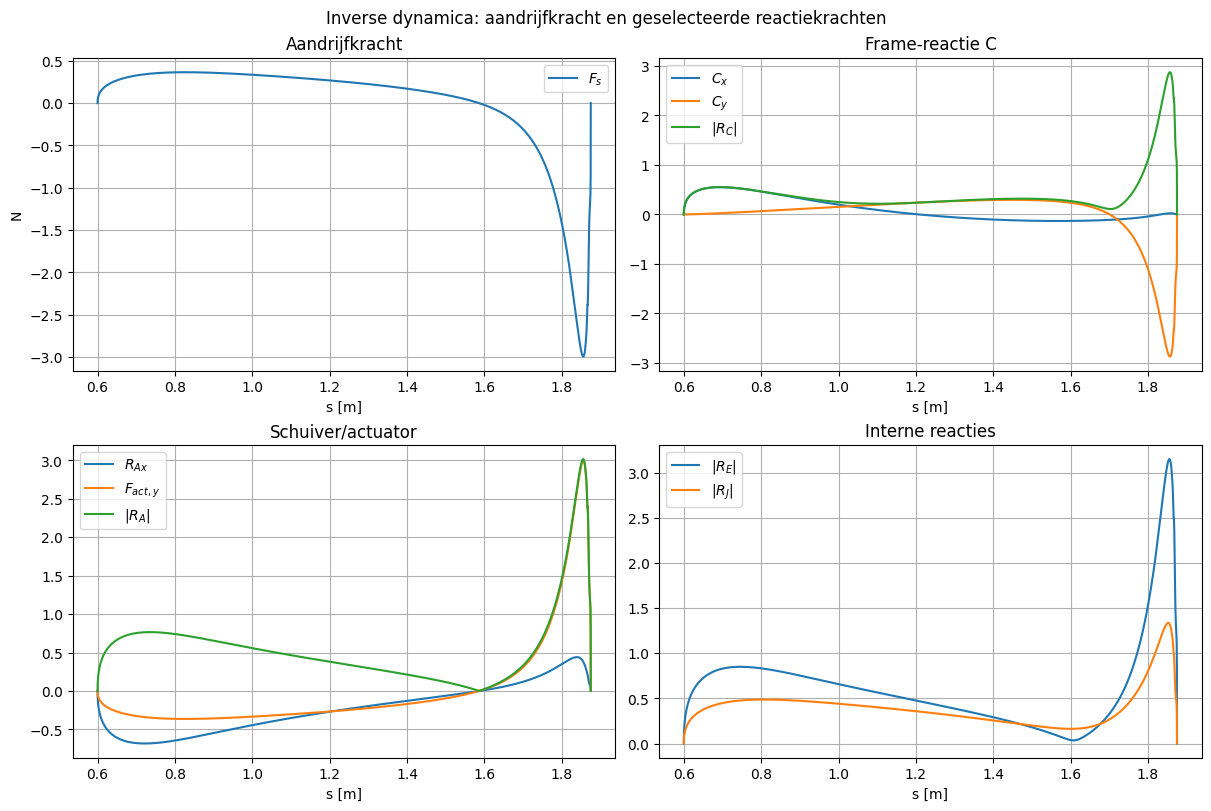

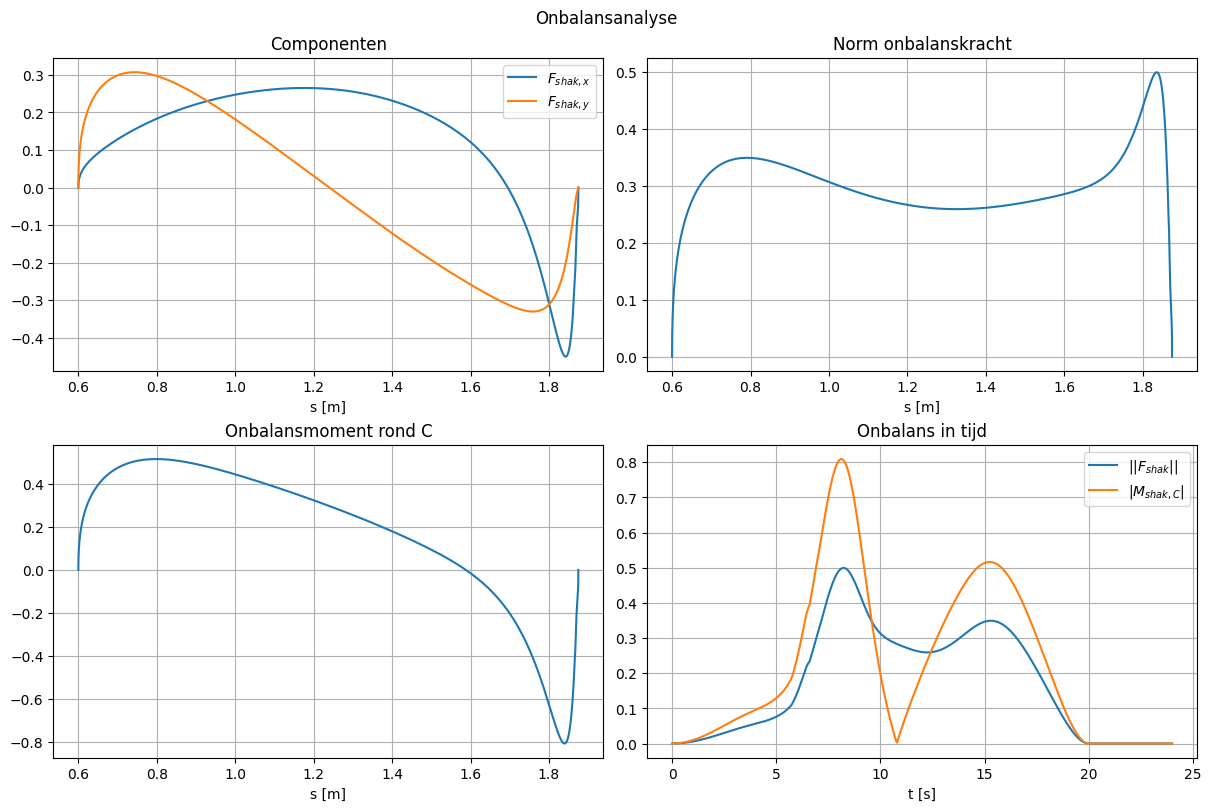

In [17]:
R_C_norm = np.linalg.norm(np.column_stack((C_x, C_y)), axis=1)
R_A_norm = np.linalg.norm(F_A_on_mechanism, axis=1)
R_E_norm = np.linalg.norm(np.column_stack((E_x, E_y)), axis=1)
R_J_norm = np.linalg.norm(np.column_stack((J_x, J_y)), axis=1)
F_shak = -F_external_total
F_shak_x = F_shak[:, 0]; F_shak_y = F_shak[:, 1]
F_shak_norm = np.linalg.norm(F_shak, axis=1)
M_shak_C = -M_external_about_C

print("Kernwaarden krachten en onbalans:")
print(f"max |F_drive_s|   = {np.max(np.abs(F_drive_s)):.3f} N")
print(f"max |R_C|         = {np.max(R_C_norm):.3f} N")
print(f"max |R_A|         = {np.max(R_A_norm):.3f} N")
print(f"max |R_E|         = {np.max(R_E_norm):.3f} N")
print(f"max |F_shak|      = {np.max(F_shak_norm):.3f} N")
print(f"max |M_shak,C|    = {np.max(np.abs(M_shak_C)):.3f} Nm")

fig_force, ax_force = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
fig_force.suptitle("Inverse dynamica: aandrijfkracht en geselecteerde reactiekrachten")
ax_force[0, 0].plot(s, F_drive_s, label=r"$F_s$"); ax_force[0, 0].set_title("Aandrijfkracht"); ax_force[0, 0].set_xlabel("s [m]"); ax_force[0, 0].set_ylabel("N"); ax_force[0, 0].grid(True); ax_force[0, 0].legend()
ax_force[0, 1].plot(s, C_x, label=r"$C_x$"); ax_force[0, 1].plot(s, C_y, label=r"$C_y$"); ax_force[0, 1].plot(s, R_C_norm, label=r"$|R_C|$"); ax_force[0, 1].set_title("Frame-reactie C"); ax_force[0, 1].set_xlabel("s [m]"); ax_force[0, 1].grid(True); ax_force[0, 1].legend()
ax_force[1, 0].plot(s, R_Ax, label=r"$R_{Ax}$"); ax_force[1, 0].plot(s, F_actuator_y, label=r"$F_{act,y}$"); ax_force[1, 0].plot(s, R_A_norm, label=r"$|R_A|$"); ax_force[1, 0].set_title("Schuiver/actuator"); ax_force[1, 0].set_xlabel("s [m]"); ax_force[1, 0].grid(True); ax_force[1, 0].legend()
ax_force[1, 1].plot(s, R_E_norm, label=r"$|R_E|$"); ax_force[1, 1].plot(s, R_J_norm, label=r"$|R_J|$"); ax_force[1, 1].set_title("Interne reacties"); ax_force[1, 1].set_xlabel("s [m]"); ax_force[1, 1].grid(True); ax_force[1, 1].legend()
plt.show()

fig_shak, ax_shak = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
fig_shak.suptitle("Onbalansanalyse")
ax_shak[0, 0].plot(s, F_shak_x, label=r"$F_{shak,x}$"); ax_shak[0, 0].plot(s, F_shak_y, label=r"$F_{shak,y}$"); ax_shak[0, 0].set_title("Componenten"); ax_shak[0, 0].set_xlabel("s [m]"); ax_shak[0, 0].grid(True); ax_shak[0, 0].legend()
ax_shak[0, 1].plot(s, F_shak_norm); ax_shak[0, 1].set_title("Norm onbalanskracht"); ax_shak[0, 1].set_xlabel("s [m]"); ax_shak[0, 1].grid(True)
ax_shak[1, 0].plot(s, M_shak_C); ax_shak[1, 0].set_title("Onbalansmoment rond C"); ax_shak[1, 0].set_xlabel("s [m]"); ax_shak[1, 0].grid(True)
ax_shak[1, 1].plot(t, F_shak_norm, label=r"$||F_{shak}||$"); ax_shak[1, 1].plot(t, np.abs(M_shak_C), label=r"$|M_{shak,C}|$"); ax_shak[1, 1].set_title("Onbalans in tijd"); ax_shak[1, 1].set_xlabel("t [s]"); ax_shak[1, 1].grid(True); ax_shak[1, 1].legend()
plt.show()

## Actuatorvermogen en poelie/riem-equivalent

Positioneermechanisme (geen continue cyclus): actuator volgt $s_{ref}(t)$ uit Notebook 1 (positiegestuurd).

$$P_{act}=F_s\dot s$$

Inertie-only → kracht in echte hold-fase ($\dot s=\ddot s=0$) is hier 0 (zie Sleutelwaarden). Poelie/riem-berekening = inertie-only equivalent; definitieve aandrijfarchitectuur (motor + as + tandriem/kabel + rem) staat in Notebook 4.

Actuatoranalyse:
piek dynamische schuifkracht        = 2.994 N
RMS dynamische schuifkracht         = 1.108 N
inertiele kracht in echte hold-fase = 0.000e+00 N
max positieve actuatorvermogen      = 0.195 W
max rem/regeneratief vermogen       = 0.070 W
netto energie over volledige run    = 2.8370e-06 J

Poelie/riem / servomotor sizing:
piek motortoerental                 = 75.1 rpm
piek motorkoppel                    = 0.1440 Nm
RMS motorkoppel tijdens bewegen     = 0.0533 Nm


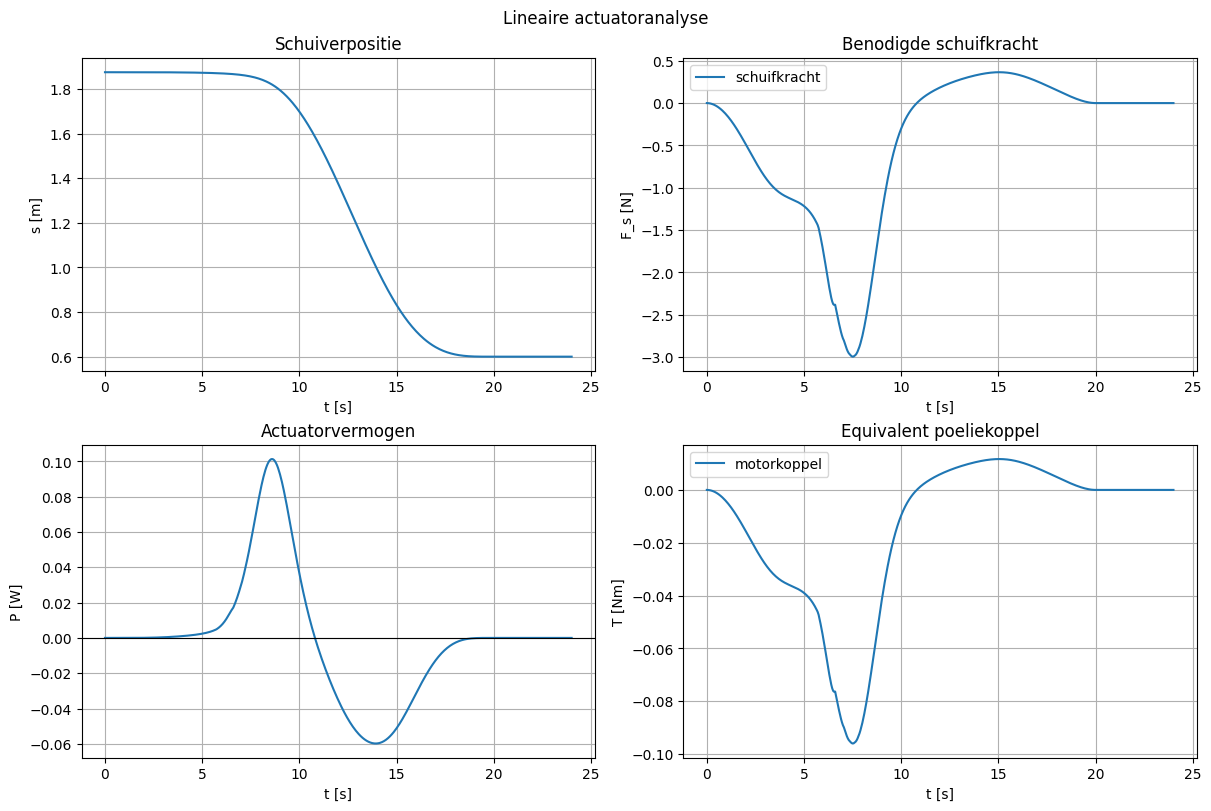

In [18]:
# ----------------------------------------------------------
# Dynamische actuatorgrootheden
# ----------------------------------------------------------
F_required_s = F_drive_s.copy()
P_act = F_required_s * ds

E_act = np.zeros_like(t)
E_act[1:] = np.cumsum(0.5 * (P_act[1:] + P_act[:-1]) * np.diff(t))
net_energy_cycle = E_act[-1] - E_act[0]
energy_fluctuation_act = np.max(E_act) - np.min(E_act)

motion_v_tol = 1e-8
motion_a_tol = 1e-8
active_motion_mask = (np.abs(ds) > motion_v_tol) | (np.abs(dds) > motion_a_tol)
hold_mask_dyn = (np.abs(ds) <= motion_v_tol) & (np.abs(dds) <= motion_a_tol)
if not np.any(active_motion_mask):
    active_motion_mask = ~hold_mask_dyn
if not np.any(hold_mask_dyn):
    hold_mask_dyn = np.zeros_like(ds, dtype=bool)
    hold_mask_dyn[np.argmin(np.abs(ds) + np.abs(dds))] = True

F_dynamic_peak = np.max(np.abs(F_required_s[active_motion_mask])) if np.any(active_motion_mask) else 0.0
F_dynamic_rms = np.sqrt(np.mean(F_required_s[active_motion_mask]**2)) if np.any(active_motion_mask) else 0.0
F_inertial_hold_peak = np.max(np.abs(F_required_s[hold_mask_dyn]))

# ----------------------------------------------------------
# Poelie/riem / roterende motor equivalent
# ----------------------------------------------------------
motor_speed_rps = ds / drive_travel_per_rev_nb2
motor_speed_rpm = 60.0 * motor_speed_rps
omega_motor = 2 * np.pi * motor_speed_rps

# Motorkoppel uit arbeid: F * ds = T * omega.
# Voor een eenvoudige sizing gebruiken we dezelfde efficientie voor beide richtingen.
T_motor = F_required_s * drive_travel_per_rev_nb2 / (2 * np.pi * actuator_efficiency)
T_motor_peak = actuator_safety_factor * np.max(np.abs(T_motor))
T_motor_rms = actuator_safety_factor * np.sqrt(np.mean(T_motor[active_motion_mask]**2)) if np.any(active_motion_mask) else 0.0
motor_speed_peak_rpm = np.max(np.abs(motor_speed_rpm))
P_positive = np.maximum(P_act, 0.0)
P_negative = np.minimum(P_act, 0.0)
P_positive_peak = actuator_safety_factor * np.max(P_positive) / actuator_efficiency
P_regen_peak = actuator_safety_factor * abs(np.min(P_negative)) * actuator_efficiency

print("Actuatoranalyse:")
print(f"piek dynamische schuifkracht        = {F_dynamic_peak:.3f} N")
print(f"RMS dynamische schuifkracht         = {F_dynamic_rms:.3f} N")
print(f"inertiele kracht in echte hold-fase = {F_inertial_hold_peak:.3e} N")
print(f"max positieve actuatorvermogen      = {P_positive_peak:.3f} W")
print(f"max rem/regeneratief vermogen       = {P_regen_peak:.3f} W")
print(f"netto energie over volledige run    = {net_energy_cycle:.4e} J")
print()
print("Poelie/riem / servomotor sizing:")
print(f"piek motortoerental                 = {motor_speed_peak_rpm:.1f} rpm")
print(f"piek motorkoppel                    = {T_motor_peak:.4f} Nm")
print(f"RMS motorkoppel tijdens bewegen     = {T_motor_rms:.4f} Nm")

fig_act, ax_act = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
fig_act.suptitle("Lineaire actuatoranalyse")
ax_act[0, 0].plot(t, s)
ax_act[0, 0].set_title("Schuiverpositie")
ax_act[0, 0].set_xlabel("t [s]")
ax_act[0, 0].set_ylabel("s [m]")
ax_act[0, 0].grid(True)

ax_act[0, 1].plot(t, F_required_s, label="schuifkracht")
ax_act[0, 1].set_title("Benodigde schuifkracht")
ax_act[0, 1].set_xlabel("t [s]")
ax_act[0, 1].set_ylabel("F_s [N]")
ax_act[0, 1].grid(True)
ax_act[0, 1].legend()

ax_act[1, 0].plot(t, P_act)
ax_act[1, 0].axhline(0.0, color="black", linewidth=0.8)
ax_act[1, 0].set_title("Actuatorvermogen")
ax_act[1, 0].set_xlabel("t [s]")
ax_act[1, 0].set_ylabel("P [W]")
ax_act[1, 0].grid(True)

ax_act[1, 1].plot(t, T_motor, label="motorkoppel")
ax_act[1, 1].set_title("Equivalent poeliekoppel")
ax_act[1, 1].set_xlabel("t [s]")
ax_act[1, 1].set_ylabel("T [Nm]")
ax_act[1, 1].grid(True)
ax_act[1, 1].legend()

plt.show()


## Arbeids-surplus en motordimensionering

$$A_\text{max}=\max_t\!\int_0^t(P-\bar P)dt-\min_t\!\int_0^t(P-\bar P)dt$$

Geen inherente eigenschap van het mechanisme — afhankelijk van de bewegingswet (hier: condition_scurve uit Notebook 1). Resultaat: zie Sleutelwaarden.

  ARBEIDS-SURPLUS EN MOTORDIMENSIONERING
P_avg  = 0.000 W   P_peak = 0.101 W   P_rms = 0.035 W
F_peak = 2.994 N   F_rms  = 1.108 N
A_max  = 0.2541 J  (energiebuffer, inertie-only)

Aanbevolen motor (inertie-only — zie NB3 voor werkelijke waarden):
  Nominaal vermogen  >= 0.05 W  (1.5 x P_rms)
  Piekvermogen       >= 0.13 W  (1.3 x P_peak)
  Piek motorkoppel   >= 0.1440 Nm
  RMS  motorkoppel   >= 0.0533 Nm


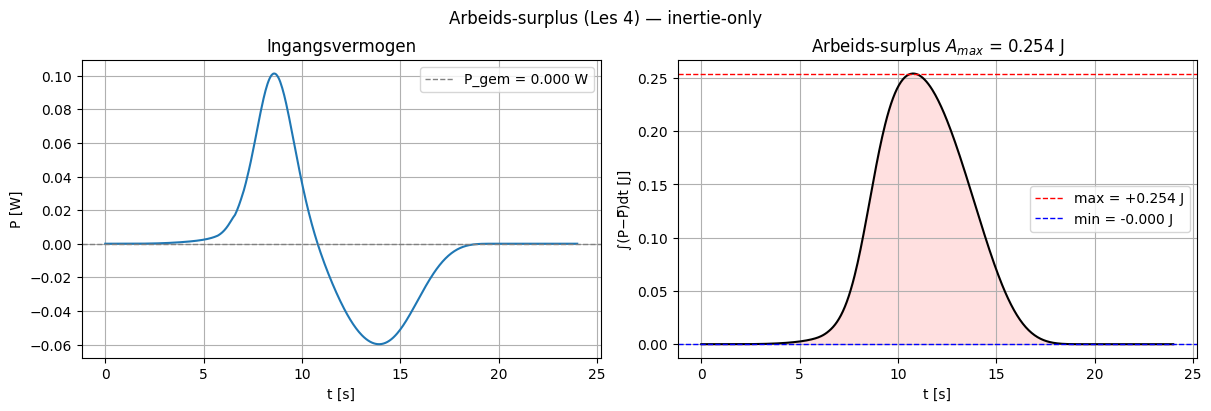

In [19]:
# Arbeids-surplus A_max (Les 4) — inertie-only

P_load_nb2  = F_drive_s * ds
P_avg_nb2   = P_load_nb2.mean()
P_peak_nb2  = np.abs(P_load_nb2).max()
P_rms_nb2   = np.sqrt(np.mean(P_load_nb2**2))
F_peak_nb2  = np.max(np.abs(F_drive_s[active_motion_mask]))
F_rms_nb2   = np.sqrt(np.mean(F_drive_s[active_motion_mask]**2))

Ts_nb2      = t[1] - t[0]
A_theta_nb2 = np.cumsum((P_load_nb2 - P_avg_nb2) * Ts_nb2)
A_max_nb2   = A_theta_nb2.max() - A_theta_nb2.min()

T_motor_peak_les4 = actuator_safety_factor * F_peak_nb2 * drive_travel_per_rev_nb2 / (2 * np.pi * actuator_efficiency)
T_motor_rms_les4  = actuator_safety_factor * F_rms_nb2  * drive_travel_per_rev_nb2 / (2 * np.pi * actuator_efficiency)
P_motor_rated_req = 1.5 * P_rms_nb2
P_motor_peak_req  = 1.3 * P_peak_nb2

print("=" * 58)
print("  ARBEIDS-SURPLUS EN MOTORDIMENSIONERING")
print("=" * 58)
print(f"P_avg  = {P_avg_nb2:.3f} W   P_peak = {P_peak_nb2:.3f} W   P_rms = {P_rms_nb2:.3f} W")
print(f"F_peak = {F_peak_nb2:.3f} N   F_rms  = {F_rms_nb2:.3f} N")
print(f"A_max  = {A_max_nb2:.4f} J  (energiebuffer, inertie-only)")
print()
print("Aanbevolen motor (inertie-only — zie NB3 voor werkelijke waarden):")
print(f"  Nominaal vermogen  >= {P_motor_rated_req:.2f} W  (1.5 x P_rms)")
print(f"  Piekvermogen       >= {P_motor_peak_req:.2f} W  (1.3 x P_peak)")
print(f"  Piek motorkoppel   >= {T_motor_peak_les4:.4f} Nm")
print(f"  RMS  motorkoppel   >= {T_motor_rms_les4:.4f} Nm")

fig_amax, ax_amax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig_amax.suptitle("Arbeids-surplus (Les 4) — inertie-only")

ax_amax[0].plot(t, P_load_nb2)
ax_amax[0].axhline(P_avg_nb2, color='gray', ls='--', lw=1, label=f'P_gem = {P_avg_nb2:.3f} W')
ax_amax[0].set_title("Ingangsvermogen")
ax_amax[0].set_xlabel("t [s]")
ax_amax[0].set_ylabel("P [W]")
ax_amax[0].grid(True)
ax_amax[0].legend()

ax_amax[1].plot(t, A_theta_nb2, 'k', lw=1.5)
ax_amax[1].axhline(A_theta_nb2.max(), color='red',  ls='--', lw=1, label=f'max = {A_theta_nb2.max():+.3f} J')
ax_amax[1].axhline(A_theta_nb2.min(), color='blue', ls='--', lw=1, label=f'min = {A_theta_nb2.min():+.3f} J')
ax_amax[1].fill_between(t, A_theta_nb2, A_theta_nb2.min(), alpha=0.12, color='red')
ax_amax[1].set_title(f"Arbeids-surplus $A_{{max}}$ = {A_max_nb2:.3f} J")
ax_amax[1].set_xlabel("t [s]")
ax_amax[1].set_ylabel("∫(P−P̅)dt [J]")
ax_amax[1].grid(True)
ax_amax[1].legend()

plt.show()

## Opslag van dynamische resultaten

Inverse-dynamicaresultaten, onbalans- en actuatorgrootheden → `notebook2_dynamica_results.npz`, startpunt voor Notebook 3 (volledige belastingsanalyse).

In [20]:
results_path = Path("notebook2_dynamica_results.npz").resolve()
np.savez(
    results_path,
    t=t, s=s, ds=ds, dds=dds,
    w_all=w_all, unknown_labels=np.array(unknown_labels),
    dyn_residual=dyn_residual, dyn_cond=dyn_cond,
    F_actuator_y=F_actuator_y, F_drive_s=F_drive_s, F_required_s=F_required_s,
    R_Ax=R_Ax, C_x=C_x, C_y=C_y, M_A=M_guide_A,
    F_shak_x=F_shak_x, F_shak_y=F_shak_y, F_shak_norm=F_shak_norm, M_shak_C=M_shak_C,
    P_act=P_act, E_act=E_act,
    T_motor=T_motor, motor_speed_rpm=motor_speed_rpm,
    T_motor_peak=T_motor_peak, T_motor_rms=T_motor_rms,
    actuator_efficiency=actuator_efficiency,
    actuator_safety_factor=actuator_safety_factor,
    drive_pulley_radius_nb2=drive_pulley_radius_nb2,
    drive_travel_per_rev_nb2=drive_travel_per_rev_nb2,
    screw_lead=screw_lead,
    P_positive_peak=P_positive_peak, P_regen_peak=P_regen_peak,
    F_dynamic_peak=F_dynamic_peak, F_dynamic_rms=F_dynamic_rms,
    F_inertial_hold_peak=F_inertial_hold_peak,
    masses=np.array([masses[i] for i in range(2, 9)]),
    inertias=np.array([inertias[i] for i in range(2, 9)]),
    payload_mass_K=payload_mass_K,
    line_mass_density=line_mass_density,
    slider_mass=slider_mass,
    rod_outer_diameter=rod_outer_diameter,
    rod_wall_thickness=rod_wall_thickness,
    rod_inner_diameter=rod_inner_diameter,
    rod_material_density=rod_material_density,
    rod_tube_area=rod_tube_area,
    rod_tube_mass_per_m=rod_tube_mass_per_m,
    rod_fittings_line_mass_allowance=rod_fittings_line_mass_allowance,
    total_model_mass=total_model_mass,
    # Arbeids-surplus (Les 4)
    A_max_nb2=A_max_nb2,
    A_theta_nb2=A_theta_nb2,
    P_avg_nb2=P_avg_nb2,
    P_peak_nb2=P_peak_nb2,
    P_rms_nb2=P_rms_nb2,
    F_peak_nb2=F_peak_nb2,
    F_rms_nb2=F_rms_nb2,
    T_motor_peak_les4=T_motor_peak_les4,
    T_motor_rms_les4=T_motor_rms_les4,
    # Energiebalans-validatie
    energy_balance_error_nb2=energy_balance_error_nb2,
    Ekin_nb2=Ekin_nb2,
)

print("Dynamische resultaten opgeslagen in:")
print(results_path)
print()
print("SAMENVATTING")
print("=" * 44)
print(f"max |F_drive_s|             : {np.max(np.abs(F_drive_s)):.3f} N")
print(f"piek actuator/schuifkracht  : {F_dynamic_peak:.3f} N")
print(f"RMS actuator/schuifkracht   : {F_dynamic_rms:.3f} N")
print(f"max |F_shak|                : {np.max(F_shak_norm):.3f} N")
print(f"max |M_shak,C|              : {np.max(np.abs(M_shak_C)):.3f} Nm")
print(f"piek poeliekoppel equivalent : {T_motor_peak:.4f} Nm")
print(f"RMS poeliekoppel equivalent  : {T_motor_rms:.4f} Nm")
print(f"piek motortoerental         : {motor_speed_peak_rpm:.1f} rpm")
print(f"arbeids-surplus A_max (Les 4) : {A_max_nb2:.4f} J")
print(f"max energiebalans-fout        : {np.nanmax(np.abs(energy_balance_error_nb2)):.3e} W")

Dynamische resultaten opgeslagen in:
C:\Users\WELL_ASUS_BUP\OneDrive\Alexandre\KUL\Semester 6\Beweging\Bewegingen-trillingen-project\project\notebooks\Stangen\notebook2_dynamica_results.npz

SAMENVATTING
max |F_drive_s|             : 2.994 N
piek actuator/schuifkracht  : 2.994 N
RMS actuator/schuifkracht   : 1.108 N
max |F_shak|                : 0.500 N
max |M_shak,C|              : 0.809 Nm
piek poeliekoppel equivalent : 0.1440 Nm
RMS poeliekoppel equivalent  : 0.0533 Nm
piek motortoerental         : 75.1 rpm
arbeids-surplus A_max (Les 4) : 0.2541 J
max energiebalans-fout        : 1.069e-04 W
